In [1]:
import pickle
from pathlib import Path
import faiss
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [3]:
PROJECT_ROOT = Path(r"C:\Users\goura\OneDrive\Desktop\image_Similarity\visual-product-search")
DATA_DIR = PROJECT_ROOT / "data"
EMBEDDING_DIR = DATA_DIR / "embeddings"
emd=np.load(EMBEDDING_DIR / "train_embeddings.npy")
labels=np.load(EMBEDDING_DIR / "train_labels.npy")
with open( EMBEDDING_DIR / "train_paths.pkl","rb") as f:
    img_path=pickle.load(f)



In [4]:
norm=faiss.normalize_L2(emd)
dim=emd.shape[1]

In [5]:
indx=faiss.IndexFlat(dim)
indx.add(emd)

In [7]:
print(indx.ntotal)

59551


In [ ]:
INDEX_DIR = PROJECT_ROOT / "data" / "faiss"
INDEX_DIR.mkdir(parents=True, exist_ok=True)

faiss.write_index(indx,str(INDEX_DIR / "product_index.faiss"))


In [9]:
indx_rwad=faiss.read_index(str(INDEX_DIR / "product_index.faiss"))

In [10]:
indx_rwad

<faiss.swigfaiss.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x000001FB3F9262F0> >

In [11]:
query=emd[100]
query=np.expand_dims(query,axis=0)

In [16]:
k=5
distances, indices=indx_rwad.search(query,k)
print(distances)
print(indices)

[[0.         0.         0.15912795 0.16739309 0.17516732]]
[[  97  100 1902 3125 3123]]


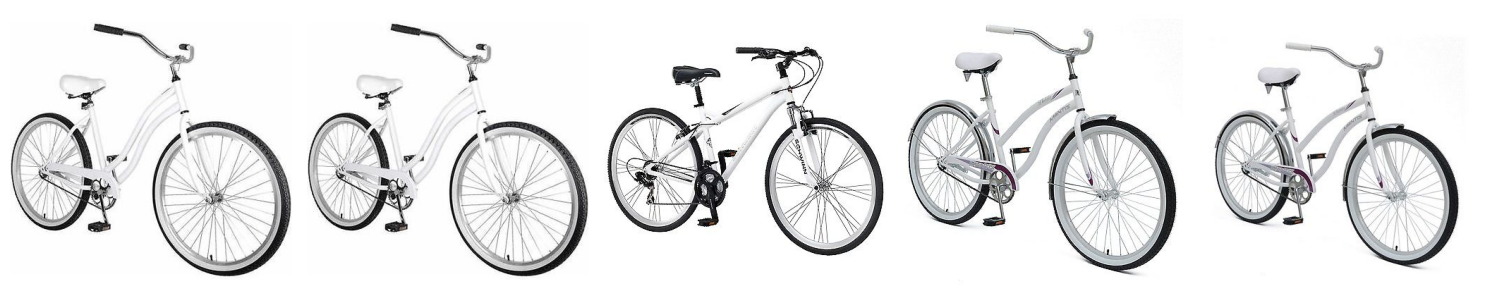

In [19]:
fig, axes = plt.subplots(1, k, figsize=(15, 5))

for ax, idx in zip(axes, indices[0]):

    img = Image.open(img_path[idx]).convert("RGB")

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
# main loggic
def search_Similar_images(query_embd, index,image_pth,k=5):
    query_embd=query_embd.astype(np.float32)
    faiss.normalize_L2(query_embd)
    dis,indc=index.search(query_embd,k)
    return dis,indc


In [32]:
# testing
query=emd[250].reshape(1,-1)
dis,indc=search_Similar_images(query,indx_rwad,img_path,k=5)

In [30]:
print(dis,indc)

[[0.         0.1540885  0.20921588 0.21360254 0.2138524 ]] [[ 250  253 2143  249 2323]]
